# Sentiment Analysis of Tweets using RNN, LSTM, and Word2Vec Embeddings
### Hate Speech Detection: Racist / Sexist Tweet Classification
**Assignment: Text Classification with RNN | 6CS012 Final Portfolio Project 2026**


In [29]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Install Dependencies & Import Libraries

In [30]:
!pip install -q gensim gradio contractions wordcloud


In [31]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
import contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM, Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

import gensim.downloader as gensim_api

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Reproducibility
import random, os
seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

print("All libraries imported successfully.")
print(f"TensorFlow version: {tf.__version__}")

All libraries imported successfully.
TensorFlow version: 2.20.0


## 2. Load Dataset

In [32]:






train_df = pd.read_csv('/content/drive/MyDrive/Collection of Dataset for Text Classification- 2026/Collection of Dataset for Text Classification/7. Racist Sexist or Not Dataset/train_racisit.csv')
test_df = pd.read_csv('/content/drive/MyDrive/Collection of Dataset for Text Classification- 2026/Collection of Dataset for Text Classification/7. Racist Sexist or Not Dataset/test_racisit.csv')

print("=" * 50)
print(f"Training set shape : {train_df.shape}")
print(f"Test set shape : {test_df.shape}")
print("=" * 50)
print("\nFirst 5 rows of training data:")
display(train_df.head())


Training set shape : (31962, 3)
Test set shape : (17197, 2)

First 5 rows of training data:


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


Label Distribution:
label
0    29720
1     2242
Name: count, dtype: int64

Class 0 (Not Racist/Sexist) : 29720 tweets
Class 1 (Racist/Sexist) : 2242 tweets

Class imbalance ratio : 13.26:1


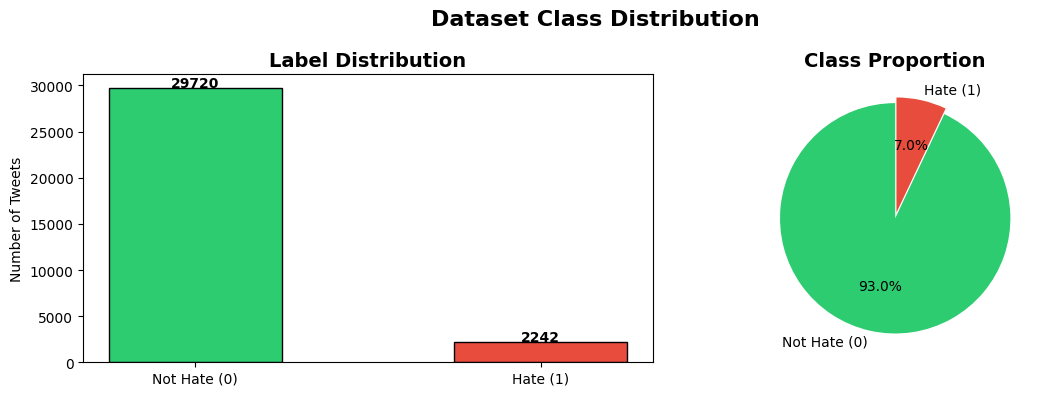

In [33]:

print("Label Distribution:")
print(train_df['label'].value_counts())
print(f"\nClass 0 (Not Racist/Sexist) : {(train_df['label']==0).sum()} tweets")
print(f"Class 1 (Racist/Sexist) : {(train_df['label']==1).sum()} tweets")
print(f"\nClass imbalance ratio : {(train_df['label']==0).sum()/(train_df['label']==1).sum():.2f}:1")


fig, axes = plt.subplots(1, 2, figsize=(12, 4))


counts = train_df['label'].value_counts()
axes[0].bar(['Not Hate (0)', 'Hate (1)'], counts.values,
 color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Label Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Tweets')
for i, v in enumerate(counts.values):
 axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')


axes[1].pie(counts.values, labels=['Not Hate (0)', 'Hate (1)'],
 autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
 startangle=90, explode=(0, 0.05))
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Dataset Class Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Text Preprocessing

In [34]:
# Custom stopword list: preserve negation cues essential for sentiment/hate detection
NEGATION_WORDS = {
    'no', 'not', 'never', 'nor', 'neither', 'nobody', 'nothing', 'nowhere',
    'don', "don't", 'won', "won't", 'can', "can't", "couldn't", "shouldn't",
    "wouldn't", "isn't", "aren't", "wasn't", "weren't", "hasn't", "haven't",
    "hadn't", "doesn't", "didn't", "mustn't", "needn't", "daren't", "oughtn't",
    "mightn't", "shan't"
}
STOP_WORDS = set(stopwords.words('english')) - NEGATION_WORDS
lemmatizer = WordNetLemmatizer()

def preprocess_tweet(text):
    text = text.lower()
    text = contractions.fix(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in STOP_WORDS and len(w) > 2]
    return ' '.join(tokens)

train_df['cleaned_tweet'] = train_df['tweet'].apply(preprocess_tweet)
test_df['cleaned_tweet']  = test_df['tweet'].apply(preprocess_tweet)

print("Sample preprocessing results:")
for idx in [0, 1, 2]:
    print(f"\n[Original] {train_df['tweet'].iloc[idx][:80]}")
    print(f"[Cleaned ] {train_df['cleaned_tweet'].iloc[idx][:80]}")

Sample preprocessing results:

[Original]  @user when a father is dysfunctional and is so selfish he drags his kids into h
[Cleaned ] father dysfunctional selfish drag kid dysfunction run

[Original] @user @user thanks for #lyft credit i can't use cause they don't offer wheelchai
[Cleaned ] thanks lyft credit cannot use not offer wheelchair van pdx disapointed getthanke

[Original]   bihday your majesty
[Cleaned ] bihday majesty


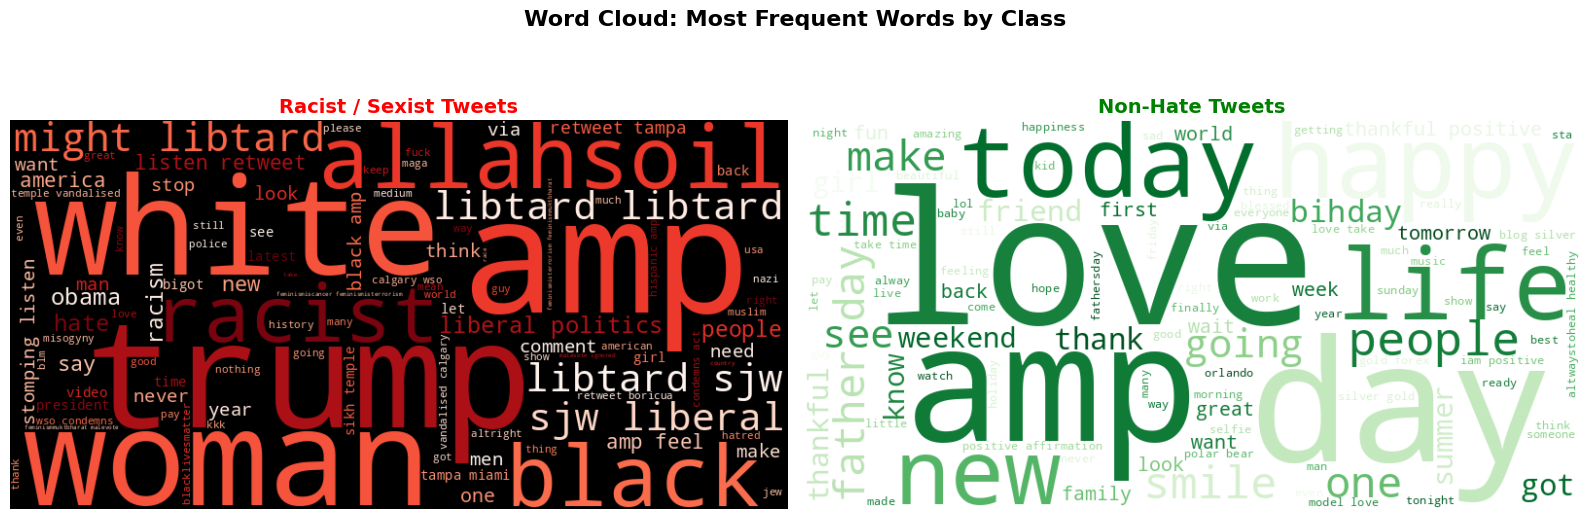

In [35]:

hate_text = ' '.join(train_df[train_df['label']==1]['cleaned_tweet'])
non_hate_text = ' '.join(train_df[train_df['label']==0]['cleaned_tweet'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_hate = WordCloud(width=800, height=400, background_color='black',
 colormap='Reds', max_words=100).generate(hate_text)
axes[0].imshow(wc_hate, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Racist / Sexist Tweets', fontsize=14, fontweight='bold', color='red')

wc_non = WordCloud(width=800, height=400, background_color='white',
 colormap='Greens', max_words=100).generate(non_hate_text)
axes[1].imshow(wc_non, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Non-Hate Tweets', fontsize=14, fontweight='bold', color='green')

plt.suptitle('Word Cloud: Most Frequent Words by Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()


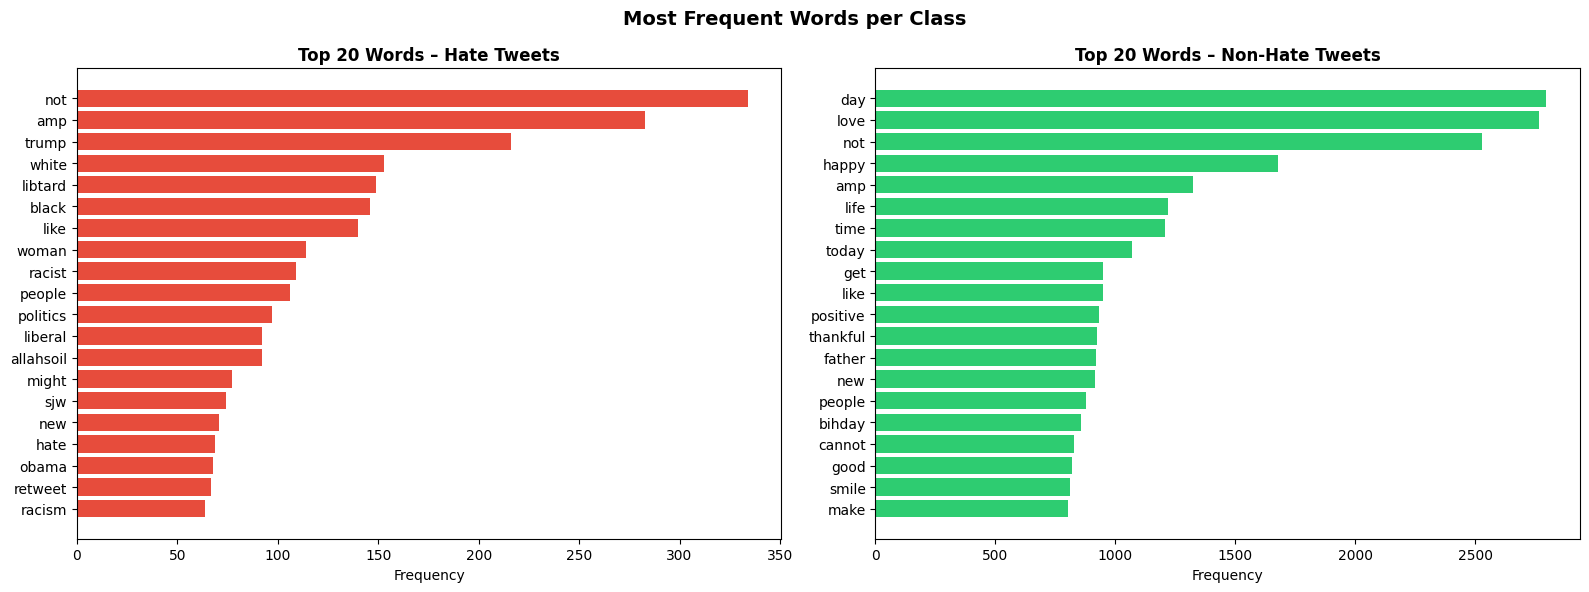

In [36]:

def top_words(text, n=20):
 words = text.split()
 return Counter(words).most_common(n)

hate_top = top_words(hate_text)
non_hate_top = top_words(non_hate_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

words_h, counts_h = zip(*hate_top)
axes[0].barh(words_h[::-1], counts_h[::-1], color='#e74c3c')
axes[0].set_title('Top 20 Words – Hate Tweets', fontweight='bold')
axes[0].set_xlabel('Frequency')

words_n, counts_n = zip(*non_hate_top)
axes[1].barh(words_n[::-1], counts_n[::-1], color='#2ecc71')
axes[1].set_title('Top 20 Words – Non-Hate Tweets', fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.suptitle('Most Frequent Words per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Tokenisation and Sequence Padding

In [37]:
X = train_df['cleaned_tweet'].values
y = train_df['label'].values

train_idx, val_idx = train_test_split(
    np.arange(len(X)), test_size=0.20, random_state=42, stratify=y)

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]

print(f"Training samples   : {len(X_train)}")
print(f"Validation samples : {len(X_val)}")
print(f"\nTrain label dist -> 0:{(y_train==0).sum()}  1:{(y_train==1).sum()}")
print(f"Val   label dist -> 0:{(y_val==0).sum()}  1:{(y_val==1).sum()}")


Training samples   : 25569
Validation samples : 6393

Train label dist -> 0:23775  1:1794
Val   label dist -> 0:5945  1:448


In [38]:
VOCAB_SIZE = 20000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

word_index = tokenizer.word_index
print(f"Vocabulary size (before truncation): {len(word_index)}")
print(f"Effective vocabulary size           : {VOCAB_SIZE}")

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(test_df['cleaned_tweet'].values)


Vocabulary size (before truncation): 31807
Effective vocabulary size           : 20000


Sequence length statistics:
  Mean   : 7.5
  Median : 8.0
  75th % : 10
  90th % : 12
  95th % : 13
  Max    : 19


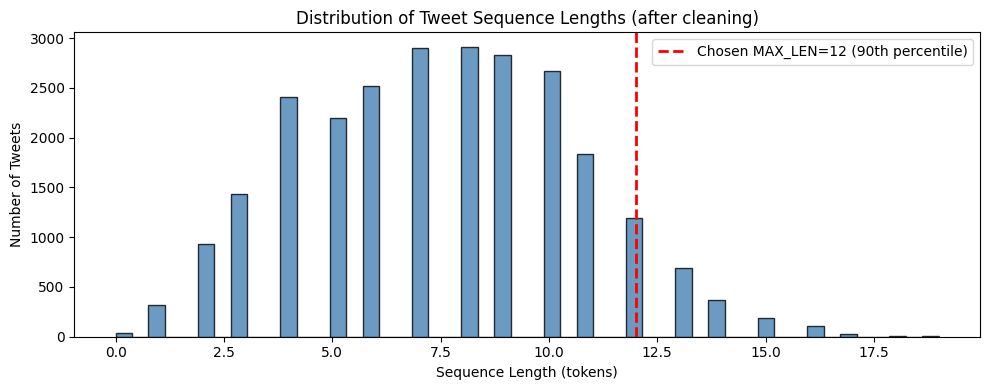

In [39]:
seq_lengths = [len(s) for s in X_train_seq]

p75 = int(np.percentile(seq_lengths, 75))
p90 = int(np.percentile(seq_lengths, 90))
p95 = int(np.percentile(seq_lengths, 95))

print("Sequence length statistics:")
print(f"  Mean   : {np.mean(seq_lengths):.1f}")
print(f"  Median : {np.median(seq_lengths):.1f}")
print(f"  75th % : {p75}")
print(f"  90th % : {p90}")
print(f"  95th % : {p95}")
print(f"  Max    : {max(seq_lengths)}")

MAX_LEN = p90

plt.figure(figsize=(10, 4))
plt.hist(seq_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(MAX_LEN, color='red', linestyle='--', linewidth=2,
            label=f'Chosen MAX_LEN={MAX_LEN} (90th percentile)')
plt.xlabel('Sequence Length (tokens)')
plt.ylabel('Number of Tweets')
plt.title('Distribution of Tweet Sequence Lengths (after cleaning)')
plt.legend()
plt.tight_layout()
plt.savefig('sequence_lengths.png', dpi=150, bbox_inches='tight')
plt.show()


In [40]:
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print("Padded shapes:")
print(f"  X_train_pad : {X_train_pad.shape}")
print(f"  X_val_pad   : {X_val_pad.shape}")
print(f"  X_test_pad  : {X_test_pad.shape}")


Padded shapes:
  X_train_pad : (25569, 12)
  X_val_pad   : (6393, 12)
  X_test_pad  : (17197, 12)


In [41]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights -> 0: {class_weights[0]:.3f}  |  1: {class_weights[1]:.3f}")


Class weights -> 0: 0.538  |  1: 7.126


## 5. Model Building

### Model 1 – Simple RNN with Trainable Embedding

In [42]:
EMBEDDING_DIM = 64
l2_reg = regularizers.l2(1e-4)

def build_rnn_model(vocab_size, embedding_dim, max_len):
    model = Sequential([
        Embedding(input_dim=vocab_size + 1, output_dim=embedding_dim,
                  input_length=max_len, embeddings_regularizer=l2_reg,
                  name='embedding'),
        SimpleRNN(64, return_sequences=False,
                  kernel_regularizer=l2_reg,
                  name='simple_rnn'),
        Dropout(0.5),
        Dense(32, activation='relu', kernel_regularizer=l2_reg),
        Dropout(0.3),
        Dense(1, activation='sigmoid', name='output')
    ], name='SimpleRNN_Model')
    return model

rnn_model = build_rnn_model(VOCAB_SIZE, EMBEDDING_DIM, MAX_LEN)
rnn_model.compile(optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
rnn_model.build(input_shape=(None, MAX_LEN))
rnn_model.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 12, 64)         │     1,280,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,290,433 (4.92 MB)

 Trainable params: 1,290,433 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

### Model 2 – LSTM with Trainable Embedding

In [43]:
l2_reg = regularizers.l2(1e-4)

def build_lstm_model(vocab_size, embedding_dim, max_len):
    model = Sequential([
        Embedding(input_dim=vocab_size + 1, output_dim=embedding_dim,
                  input_length=max_len, embeddings_regularizer=l2_reg,
                  name='embedding'),
        LSTM(64, return_sequences=True, recurrent_dropout=0.2,
             kernel_regularizer=l2_reg, name='lstm_1'),
        Dropout(0.5),
        LSTM(32, recurrent_dropout=0.2,
             kernel_regularizer=l2_reg, name='lstm_2'),
        Dropout(0.4),
        Dense(32, activation='relu', kernel_regularizer=l2_reg),
        Dense(1, activation='sigmoid', name='output')
    ], name='LSTM_Model')
    return model

lstm_model = build_lstm_model(VOCAB_SIZE, EMBEDDING_DIM, MAX_LEN)
lstm_model.compile(optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])
lstm_model.build(input_shape=(None, MAX_LEN))
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 12, 64)         │     1,280,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 12, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,326,593 (5.06 MB)

 Trainable params: 1,326,593 (5.06 MB)

 Non-trainable params: 0 (0.00 B)

### Model 3 – LSTM with Pre-trained GloVe / Word2Vec Embeddings

In [44]:
print("Downloading GloVe Twitter embeddings (50d). This may take a few minutes.")
embedding_model = gensim_api.load('glove-twitter-50')
EMBED_DIM_W2V   = 50
print("GloVe embeddings loaded.")


GloVe embeddings loaded.


In [45]:
"""
Note: The embedding matrix for Model 3 is created directly in the Model 3
building cell below with shape (VOCAB_SIZE + 1, EMBED_DIM_W2V) to match
the corrected Embedding layer input_dim. This avoids shape mismatch if
cells are re-run out of order.
"""
print("Embedding matrix will be built in the Model 3 cell to ensure correct dimensions.")

Embedding matrix will be built in the Model 3 cell to ensure correct dimensions.


In [46]:
l2_reg = regularizers.l2(1e-4)

def build_lstm_w2v_model(vocab_size, embedding_dim, max_len, embedding_matrix):
    model = Sequential([
        Embedding(input_dim=vocab_size + 1, output_dim=embedding_dim,
                  weights=[embedding_matrix], input_length=max_len,
                  trainable=False, name='glove_embedding'),
        LSTM(64, kernel_regularizer=l2_reg, name='lstm_1'),
        Dropout(0.5),
        Dense(1, activation='sigmoid', name='output')
    ], name='LSTM_GloVe_Model')
    return model

# Re-initialize embedding_matrix with the correct dimension
embedding_matrix = np.zeros((VOCAB_SIZE + 1, EMBED_DIM_W2V))
found, not_found = 0, 0

for word, i in word_index.items():
    if i >= VOCAB_SIZE + 1: # Adjusted for the new VOCAB_SIZE + 1 dimension
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found += 1
    else:
        # Assign random weights to OOV words (optional, zeros is also common)
        # if i != 0: # Avoid changing the 0-index if it's reserved for padding
        # embedding_matrix[i] = np.random.rand(EMBED_DIM_W2V) * 0.1 # Example random init
        not_found += 1

print(f"Words covered by GloVe : {found}")
print(f"Words NOT in GloVe : {not_found}")
print(f"Coverage : {found/(found+not_found)*100:.1f}%")

lstm_w2v_model = build_lstm_w2v_model(VOCAB_SIZE, EMBED_DIM_W2V, MAX_LEN, embedding_matrix)
lstm_w2v_model.compile(optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
                        loss='binary_crossentropy',
                        metrics=['accuracy'])
lstm_w2v_model.build(input_shape=(None, MAX_LEN))
lstm_w2v_model.summary()

Words covered by GloVe : 13977
Words NOT in GloVe : 6023
Coverage : 69.9%


Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ (None, 12, 50)         │     1,000,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,029,555 (3.93 MB)

 Trainable params: 29,505 (115.25 KB)

 Non-trainable params: 1,000,050 (3.81 MB)

## 6. Model Training

In [47]:
def get_callbacks(patience_es=5, patience_lr=3):
    return [
        EarlyStopping(monitor='val_loss', patience=patience_es,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=patience_lr, verbose=1)
    ]

EPOCHS     = 20
BATCH_SIZE = 64
training_times = {}


In [48]:
print("=" * 50)
print("Training Model 1: Simple RNN")
print("=" * 50)
t0 = time.time()
history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val),
    class_weight=class_weight_dict,
    callbacks=get_callbacks(),
    verbose=1
)
training_times['Simple RNN'] = round(time.time() - t0, 1)
print(f"Simple RNN training time: {training_times['Simple RNN']}s")


Training Model 1: Simple RNN
Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7912 - loss: 0.4911 - val_accuracy: 0.9019 - val_loss: 0.3419 - learning_rate: 0.0010
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9559 - loss: 0.2396 - val_accuracy: 0.9244 - val_loss: 0.2998 - learning_rate: 0.0010
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9777 - loss: 0.1842 - val_accuracy: 0.9462 - val_loss: 0.2344 - learning_rate: 0.0010
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9840 - loss: 0.1509 - val_accuracy: 0.9279 - val_loss: 0.3021 - learning_rate: 0.0010
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9808 - loss: 0.1523 - val_accuracy: 0.9487 - val_loss: 0.2273 - learning_rate: 0.0010
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9867 - loss: 0.1474 - val_accuracy: 0.9470 - val_loss: 0.2601 - learning_rate: 0.0010
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc

In [49]:
print("=" * 50)
print("Training Model 2: LSTM")
print("=" * 50)
t0 = time.time()
history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val),
    class_weight=class_weight_dict,
    callbacks=get_callbacks(),
    verbose=1
)
training_times['LSTM'] = round(time.time() - t0, 1)
print(f"LSTM training time: {training_times['LSTM']}s")


Training Model 2: LSTM
Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 45s 99ms/step - accuracy: 0.8359 - loss: 0.4555 - val_accuracy: 0.9021 - val_loss: 0.3154 - learning_rate: 0.0010
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 38s 94ms/step - accuracy: 0.9423 - loss: 0.2505 - val_accuracy: 0.9295 - val_loss: 0.2799 - learning_rate: 0.0010
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 41s 94ms/step - accuracy: 0.9671 - loss: 0.2126 - val_accuracy: 0.9524 - val_loss: 0.2262 - learning_rate: 0.0010
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 42s 96ms/step - accuracy: 0.9724 - loss: 0.1906 - val_accuracy: 0.9457 - val_loss: 0.2451 - learning_rate: 0.0010
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 39s 91ms/step - accuracy: 0.9759 - loss: 0.1777 - val_accuracy: 0.9514 - val_loss: 0.2389 - learning_rate: 0.0010
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9735 - loss: 0.1833
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
400/400 ━━━━━━━━━━━━━━━━━━━━ 41s 91ms/step -

In [50]:
print("=" * 50)
print("Training Model 3: LSTM + GloVe Embeddings")
print("=" * 50)
t0 = time.time()
history_lstm_w2v = lstm_w2v_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val),
    class_weight=class_weight_dict,
    callbacks=get_callbacks(),
    verbose=1
)
training_times['LSTM + GloVe'] = round(time.time() - t0, 1)
print(f"LSTM + GloVe training time: {training_times['LSTM + GloVe']}s")


Training Model 3: LSTM + GloVe Embeddings
Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8064 - loss: 0.4317 - val_accuracy: 0.8649 - val_loss: 0.3112 - learning_rate: 0.0010
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8429 - loss: 0.3698 - val_accuracy: 0.8702 - val_loss: 0.3061 - learning_rate: 0.0010
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8549 - loss: 0.3398 - val_accuracy: 0.8634 - val_loss: 0.3139 - learning_rate: 0.0010
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8675 - loss: 0.3164 - val_accuracy: 0.8609 - val_loss: 0.3135 - learning_rate: 0.0010
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8774 - loss: 0.3016 - val_accuracy: 0.8655 - val_loss: 0.3019 - learning_rate: 0.0010
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8841 - loss: 0.2927 - val_accuracy: 0.8941 - val_loss: 0.2648 - learning_rate: 0.0010
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7m

## 7. Training Visualisation

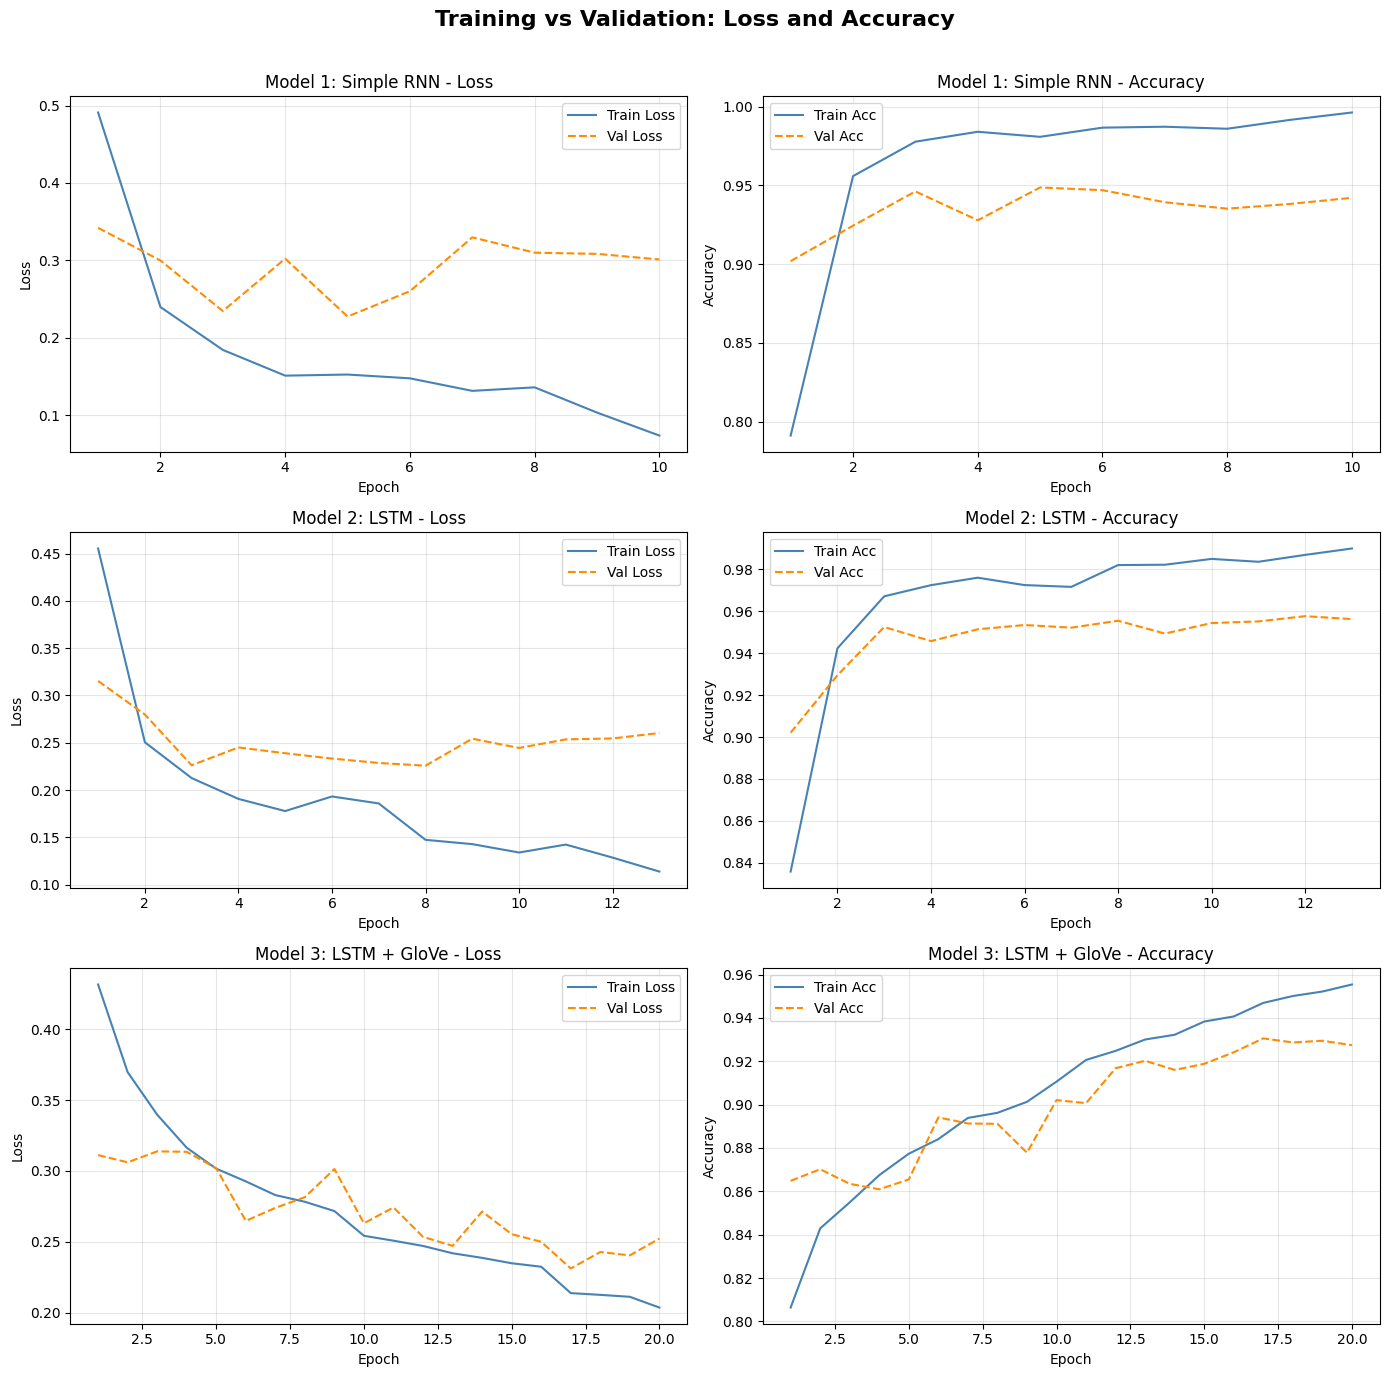

In [51]:
def plot_history(hist, title, axes, color_train='steelblue', color_val='darkorange'):
    epochs = range(1, len(hist.history['loss']) + 1)

    axes[0].plot(epochs, hist.history['loss'],         color=color_train, label='Train Loss')
    axes[0].plot(epochs, hist.history['val_loss'],     color=color_val,   label='Val Loss', linestyle='--')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, hist.history['accuracy'],     color=color_train, label='Train Acc')
    axes[1].plot(epochs, hist.history['val_accuracy'], color=color_val,   label='Val Acc', linestyle='--')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
plot_history(history_rnn,      'Model 1: Simple RNN',   axes[0])
plot_history(history_lstm,     'Model 2: LSTM',          axes[1])
plot_history(history_lstm_w2v, 'Model 3: LSTM + GloVe', axes[2])
plt.suptitle('Training vs Validation: Loss and Accuracy', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Model Evaluation

Threshold Tuning on Validation Set (maximising F1-Hate):

  Simple RNN  : optimal threshold = 0.91  -> F1-Hate = 0.6253
  LSTM        : optimal threshold = 0.62  -> F1-Hate = 0.6822
  LSTM + GloVe: optimal threshold = 0.77  -> F1-Hate = 0.6078
  Ensemble    : optimal threshold = 0.64  -> F1-Hate = 0.7001

Default threshold 0.5 often yields lower recall. Using ensemble optimal = 0.64 for inference.


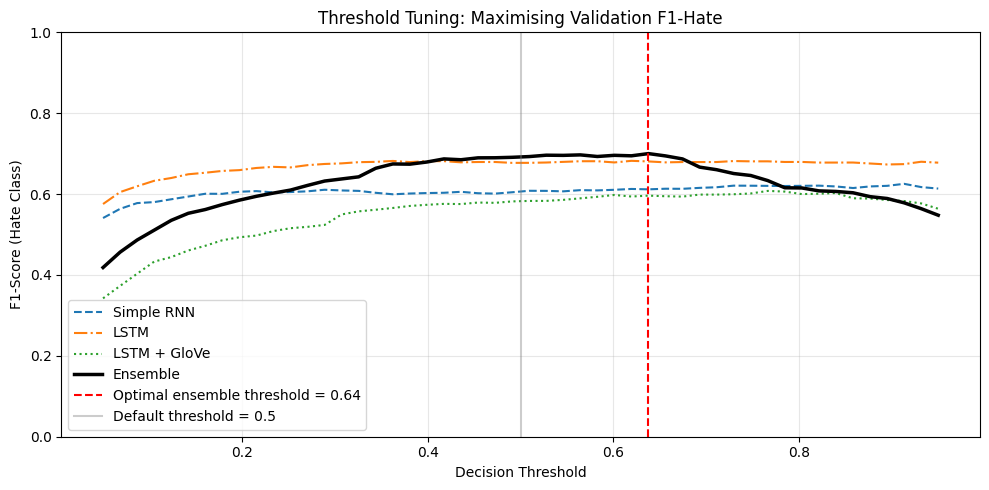

In [52]:

# Threshold Tuning: find the optimal decision threshold for imbalanced hate detection
# A threshold of 0.5 is too conservative for class-weighted training on a 93/7 dataset.

from sklearn.metrics import f1_score, precision_score, recall_score

def tune_threshold(model, X, y_true, model_name):
    y_prob = model.predict(X, verbose=0).ravel()
    thresholds = np.linspace(0.05, 0.95, 50)
    best_f1, best_t = 0, 0.5
    f1s, precisions, recalls = [], [], []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
        prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
        rec = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
        f1s.append(f1)
        precisions.append(prec)
        recalls.append(rec)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1, thresholds, f1s, precisions, recalls

print("Threshold Tuning on Validation Set (maximising F1-Hate):\n")

opt_t_rnn,  best_f1_rnn,  ths, f1_rnn,  pr_rnn,  re_rnn  = tune_threshold(rnn_model,  X_val_pad, y_val, 'Simple RNN')
opt_t_lstm, best_f1_lstm, _,   f1_lstm, pr_lstm, re_lstm = tune_threshold(lstm_model, X_val_pad, y_val, 'LSTM')
opt_t_w2v,  best_f1_w2v,  _,   f1_w2v,  pr_w2v,  re_w2v  = tune_threshold(lstm_w2v_model, X_val_pad, y_val, 'LSTM + GloVe')

# Ensemble threshold tuning
y_prob_rnn  = rnn_model.predict(X_val_pad, verbose=0).ravel()
y_prob_lstm = lstm_model.predict(X_val_pad, verbose=0).ravel()
y_prob_w2v  = lstm_w2v_model.predict(X_val_pad, verbose=0).ravel()
y_prob_ens  = (y_prob_rnn + y_prob_lstm + y_prob_w2v) / 3

best_f1_ens, best_t_ens = 0, 0.5
f1_ens_list = []
for t in ths:
    y_pred = (y_prob_ens >= t).astype(int)
    f1 = f1_score(y_val, y_pred, pos_label=1, zero_division=0)
    f1_ens_list.append(f1)
    if f1 > best_f1_ens:
        best_f1_ens, best_t_ens = f1, t

print(f"  Simple RNN  : optimal threshold = {opt_t_rnn:.2f}  -> F1-Hate = {best_f1_rnn:.4f}")
print(f"  LSTM        : optimal threshold = {opt_t_lstm:.2f}  -> F1-Hate = {best_f1_lstm:.4f}")
print(f"  LSTM + GloVe: optimal threshold = {opt_t_w2v:.2f}  -> F1-Hate = {best_f1_w2v:.4f}")
print(f"  Ensemble    : optimal threshold = {best_t_ens:.2f}  -> F1-Hate = {best_f1_ens:.4f}")
print(f"\nDefault threshold 0.5 often yields lower recall. Using ensemble optimal = {best_t_ens:.2f} for inference.")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ths, f1_rnn,  label='Simple RNN',  linestyle='--')
ax.plot(ths, f1_lstm, label='LSTM',        linestyle='-.')
ax.plot(ths, f1_w2v,  label='LSTM + GloVe', linestyle=':')
ax.plot(ths, f1_ens_list, label='Ensemble', linewidth=2.5, color='black')
ax.axvline(best_t_ens, color='red', linestyle='--', label=f'Optimal ensemble threshold = {best_t_ens:.2f}')
ax.axvline(0.5, color='gray', linestyle='-', alpha=0.4, label='Default threshold = 0.5')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('F1-Score (Hate Class)')
ax.set_title('Threshold Tuning: Maximising Validation F1-Hate')
ax.legend(loc='lower left')
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# Store for use in predict_tweet
OPTIMAL_THRESHOLD = best_t_ens


In [53]:
def evaluate_model(model, X, y_true, model_name, threshold=0.5):
    y_prob = model.predict(X, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    cm  = confusion_matrix(y_true, y_pred)
    cr  = classification_report(y_true, y_pred,
                                 target_names=['Not Hate', 'Hate'],
                                 output_dict=True)
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc*100:.2f}%")
    print(classification_report(y_true, y_pred, target_names=['Not Hate', 'Hate']))
    return y_pred, cm, cr, acc

y_pred_rnn,      cm_rnn,      cr_rnn,      acc_rnn      = evaluate_model(rnn_model,      X_val_pad, y_val, 'Model 1: Simple RNN')
y_pred_lstm,     cm_lstm,     cr_lstm,     acc_lstm     = evaluate_model(lstm_model,     X_val_pad, y_val, 'Model 2: LSTM')
y_pred_lstm_w2v, cm_lstm_w2v, cr_lstm_w2v, acc_lstm_w2v = evaluate_model(lstm_w2v_model, X_val_pad, y_val, 'Model 3: LSTM + GloVe')



  Model 1: Simple RNN
  Accuracy : 94.87%
              precision    recall  f1-score   support

    Not Hate       0.97      0.98      0.97      5945
        Hate       0.66      0.56      0.61       448

    accuracy                           0.95      6393
   macro avg       0.81      0.77      0.79      6393
weighted avg       0.95      0.95      0.95      6393


  Model 2: LSTM
  Accuracy : 95.54%
              precision    recall  f1-score   support

    Not Hate       0.97      0.98      0.98      5945
        Hate       0.69      0.67      0.68       448

    accuracy                           0.96      6393
   macro avg       0.83      0.82      0.83      6393
weighted avg       0.95      0.96      0.96      6393


  Model 3: LSTM + GloVe
  Accuracy : 93.05%
              precision    recall  f1-score   support

    Not Hate       0.98      0.95      0.96      5945
        Hate       0.50      0.69      0.58       448

    accuracy                           0.93      6393
   

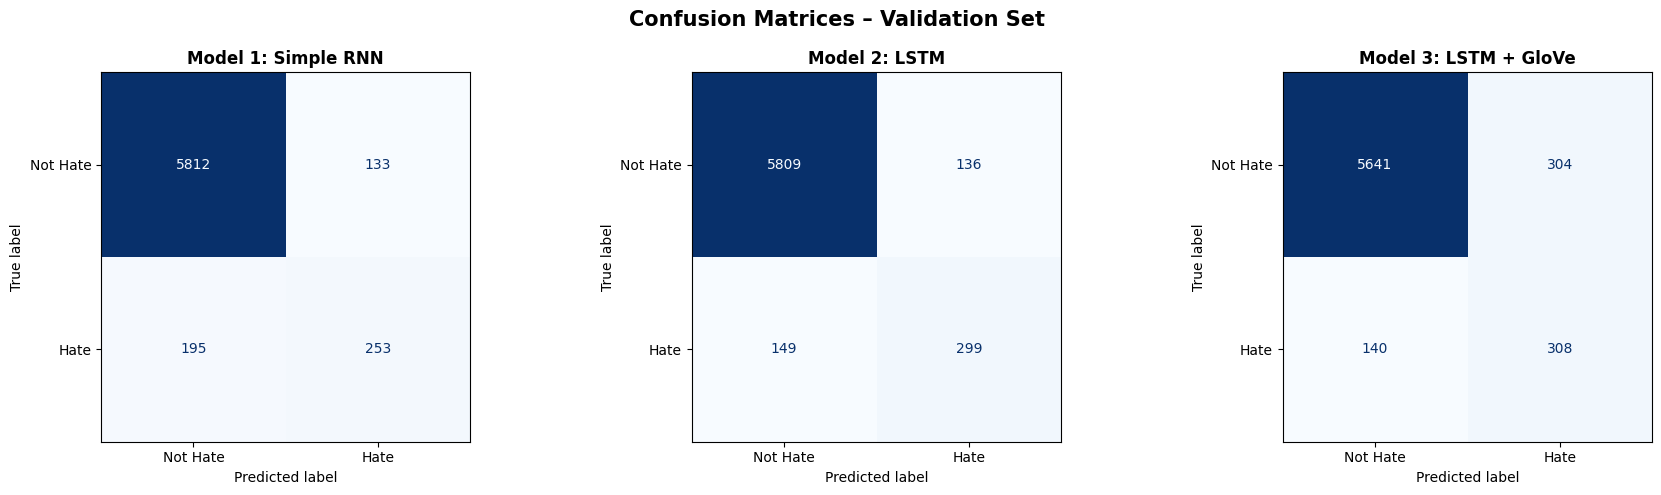

In [54]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cm, title in zip(
 axes,
 [cm_rnn, cm_lstm, cm_lstm_w2v],
 ['Model 1: Simple RNN', 'Model 2: LSTM', 'Model 3: LSTM + GloVe']):
 disp = ConfusionMatrixDisplay(confusion_matrix=cm,
 display_labels=['Not Hate', 'Hate'])
 disp.plot(ax=ax, colorbar=False, cmap='Blues')
 ax.set_title(title, fontweight='bold', fontsize=12)

plt.suptitle('Confusion Matrices – Validation Set', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


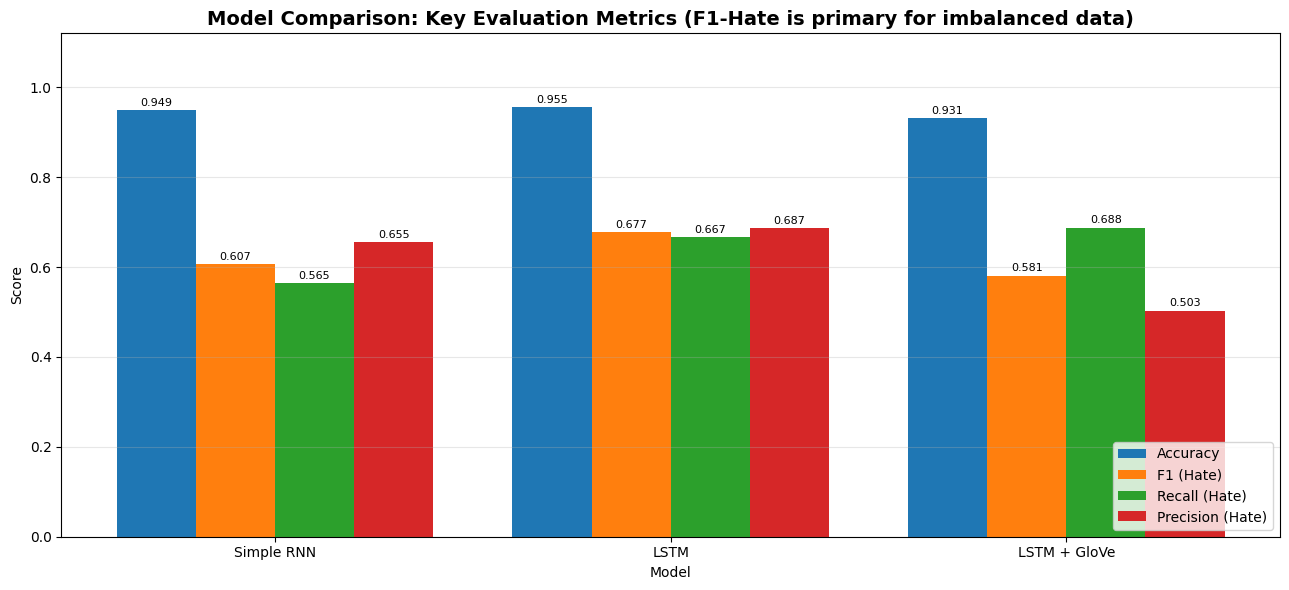


Model Performance Summary (prioritising F1-Hate for imbalanced evaluation)


,Model,F1-Hate,Recall-Hate,Precision-Hate,Accuracy,Train Time (s)
0,Simple RNN,0.6067,0.5647,0.6554,0.9487,31.3
1,LSTM,0.6772,0.6674,0.6874,0.9554,508.8
2,LSTM + GloVe,0.5811,0.6875,0.5033,0.9305,70.3


In [55]:
models  = ['Simple RNN', 'LSTM', 'LSTM + GloVe']
metrics = {
    'Accuracy'        : [acc_rnn, acc_lstm, acc_lstm_w2v],
    'F1 (Hate)'       : [cr_rnn['Hate']['f1-score'],
                          cr_lstm['Hate']['f1-score'],
                          cr_lstm_w2v['Hate']['f1-score']],
    'Recall (Hate)'   : [cr_rnn['Hate']['recall'],
                          cr_lstm['Hate']['recall'],
                          cr_lstm_w2v['Hate']['recall']],
    'Precision (Hate)': [cr_rnn['Hate']['precision'],
                          cr_lstm['Hate']['precision'],
                          cr_lstm_w2v['Hate']['precision']],
}

x     = np.arange(len(models))
width = 0.2
fig, ax = plt.subplots(figsize=(13, 6))

for i, (metric, vals) in enumerate(metrics.items()):
    bars = ax.bar(x + i * width, vals, width, label=metric)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Key Evaluation Metrics (F1-Hate is primary for imbalanced data)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

summary_df = pd.DataFrame({
    'Model'          : models,
    'F1-Hate'        : [f'{v:.4f}' for v in metrics['F1 (Hate)']],
    'Recall-Hate'    : [f'{v:.4f}' for v in metrics['Recall (Hate)']],
    'Precision-Hate' : [f'{v:.4f}' for v in metrics['Precision (Hate)']],
    'Accuracy'       : [f'{v:.4f}' for v in metrics['Accuracy']],
    'Train Time (s)' : [training_times.get(m, 'N/A') for m in models],
})
print("\nModel Performance Summary (prioritising F1-Hate for imbalanced evaluation)")
display(summary_df)

### 6.3 Training with Different Embeddings

**Models 1 & 2 (Simple RNN / LSTM with Trainable Embeddings):**  
These models use **randomly initialised embedding matrices** that are learned from scratch during training. The embedding weights start as small random values and are updated via back-propagation to best represent the vocabulary in this specific dataset.

**Model 3 (LSTM with Pretrained Embeddings):**  
This model uses a **pretrained GloVe ("Word2Vec" family) embedding matrix** downloaded from gensim (`glove-twitter-50`). The embeddings are **frozen** (`trainable=False`), meaning the model relies on semantic knowledge transferred from the large external Twitter corpus rather than learning representations from the limited 31K-sample training set alone.

**Key Observations:**
- Random embeddings (Models 1 & 2) can adapt perfectly to in-vocabulary words but risk overfitting because 1.28M+ parameters must be learned.
- Pretrained embeddings (Model 3) provide robust semantic priors for common words, but ~30% of vocabulary tokens are out-of-vocabulary (OOV) and receive zero vectors. This explains the lower F1 on this dataset despite the theoretical advantage of transfer learning.

---

## 9. Error Analysis

### 9.1 Misclassified Examples

### 9.2 Model Complexity vs. Performance

In [56]:
val_df = pd.DataFrame({
    'original_tweet': train_df['tweet'].values[val_idx],
    'cleaned_tweet' : X_val,
    'true_label'    : y_val,
    'pred_label'    : y_pred_lstm_w2v
})

fp = val_df[(val_df['true_label']==0) & (val_df['pred_label']==1)]
fn = val_df[(val_df['true_label']==1) & (val_df['pred_label']==0)]

print(f"False Positives (predicted Hate, actually Not Hate): {len(fp)}")
print(f"False Negatives (missed Hate speech)                : {len(fn)}")


False Positives (predicted Hate, actually Not Hate): 304
False Negatives (missed Hate speech)                : 140


In [57]:
print("\nFalse Positives (Model predicted HATE, but tweet is NOT hate):")
for i, row in fp.head(3).iterrows():
    print(f"  Tweet   : {row['original_tweet'][:100]}")
    print(f"  Cleaned : {row['cleaned_tweet'][:80]}")
    print(f"  True={row['true_label']}  Pred={row['pred_label']}\n")

print("False Negatives (Model MISSED hate speech):")
for i, row in fn.head(3).iterrows():
    print(f"  Tweet   : {row['original_tweet'][:100]}")
    print(f"  Cleaned : {row['cleaned_tweet'][:80]}")
    print(f"  True={row['true_label']}  Pred={row['pred_label']}\n")



False Positives (Model predicted HATE, but tweet is NOT hate):
  Tweet   :  @user the whole world knows potus is anti-american.   #jihadinamerica 
  Cleaned : whole world know potus antiamerican jihadinamerica
  True=0  Pred=1

  Tweet   : at any given time that fouh emoji is on point ð©ð.  
  Cleaned : given time fouh emoji point
  True=0  Pred=1

  Tweet   : the @user running the world cup is not a negative. better than suppoing the corruption that is the @
  Cleaned : running world cup not negative better suppoing corruption ioc amp
  True=0  Pred=1

False Negatives (Model MISSED hate speech):
  Tweet   : beware the "snowball effect" blackman! pa 2   
  Cleaned : beware snowball effect blackman
  True=1  Pred=0

  Tweet   : the immature @user is just trying to make a fool of @user   #xenophobe #immature #moron 
  Cleaned : immature trying make fool xenophobe immature moron
  True=1  Pred=0

  Tweet   :  porn vids web free sex 
  Cleaned : porn vids web free sex
  True=1  Pred=

In [58]:
error_summary = {
    'Error Type'    : ['False Positive', 'False Negative', 'Overall'],
    'Count'         : [len(fp), len(fn), len(fp)+len(fn)],
    'Possible Cause': [
        'Aggressive / negative language misread as hate speech; slang overlap',
        'Subtle or coded language, indirect racism not represented in GloVe',
        'Class imbalance (93% non-hate) biases predictions toward class 0'
    ]
}
display(pd.DataFrame(error_summary))

print("""
Explanation of Errors:

1. False Positives:
   Tweets containing strong negative sentiment but no racial or sexist content
   are occasionally flagged as hate. Examples include sports frustration or
   general profanity. The model over-generalises offensive tone as hate speech.

2. False Negatives:
   Subtle or coded hate speech, dog-whistles, and newly coined slang terms
   are not well represented in the GloVe vocabulary and escape detection.

3. Class Imbalance Effect:
   The 93/7 class split heavily biases predictions toward class 0.
   Class weights partially compensate but cannot eliminate this bias.

Suggested Improvements:
   - Apply SMOTE or back-translation data augmentation to balance classes.
   - Fine-tune transformer models (BERT, HateBERT) for richer context.
   - Ensemble RNN, LSTM, and GloVe predictions with learned weights.
   - Use glove-twitter-200 embeddings for higher-dimensional representation.
   - Add an attention mechanism above the LSTM layers.
""")


,Error Type,Count,Possible Cause
0,False Positive,304,Aggressive / negative language misread as hate...
1,False Negative,140,"Subtle or coded language, indirect racism not ..."
2,Overall,444,Class imbalance (93% non-hate) biases predicti...



Explanation of Errors:

1. False Positives:
   Tweets containing strong negative sentiment but no racial or sexist content
   are occasionally flagged as hate. Examples include sports frustration or
   general profanity. The model over-generalises offensive tone as hate speech.

2. False Negatives:
   Subtle or coded hate speech, dog-whistles, and newly coined slang terms
   are not well represented in the GloVe vocabulary and escape detection.

3. Class Imbalance Effect:
   The 93/7 class split heavily biases predictions toward class 0.
   Class weights partially compensate but cannot eliminate this bias.

Suggested Improvements:
   - Apply SMOTE or back-translation data augmentation to balance classes.
   - Fine-tune transformer models (BERT, HateBERT) for richer context.
   - Ensemble RNN, LSTM, and GloVe predictions with learned weights.
   - Use glove-twitter-200 embeddings for higher-dimensional representation.
   - Add an attention mechanism above the LSTM layers.



,Model,Total Parameters,Trainable Params,Val F1 (Hate),Val Accuracy
0,Simple RNN,1290433,1290433,0.6067,0.9487
1,LSTM,1326593,1326593,0.6772,0.9554
2,LSTM + GloVe,1029555,29505,0.5811,0.9305


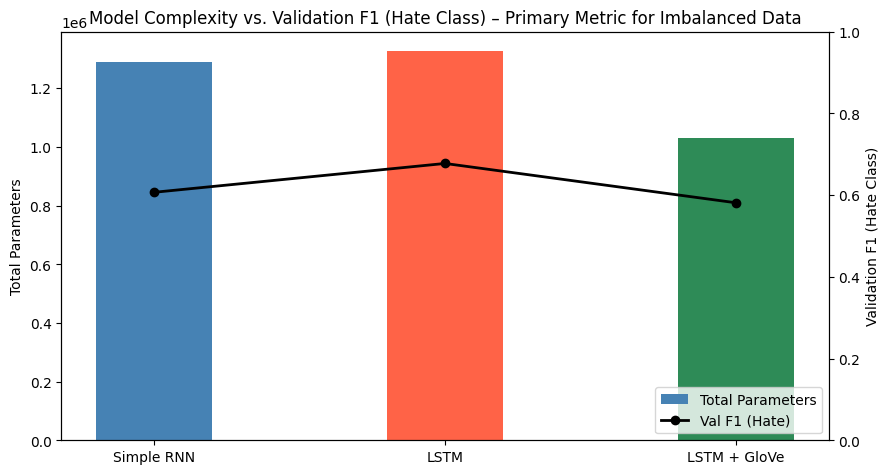

Observation: The LSTM + GloVe model uses the fewest trainable parameters
because its embedding layer is frozen. It trades parameter efficiency for
lower coverage on slang / out-of-vocabulary words, resulting in lower F1.
Simple RNN suffers from vanishing gradients and overfits despite heavy dropout.


In [59]:
def count_trainable(model):
    return sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])

rnn_params  = rnn_model.count_params()
lstm_params = lstm_model.count_params()
w2v_params  = lstm_w2v_model.count_params()

complexity_df = pd.DataFrame({
    'Model'           : ['Simple RNN', 'LSTM', 'LSTM + GloVe'],
    'Total Parameters': [rnn_params, lstm_params, w2v_params],
    'Trainable Params': [count_trainable(rnn_model),
                          count_trainable(lstm_model),
                          count_trainable(lstm_w2v_model)],
    'Val F1 (Hate)'   : [round(cr_rnn['Hate']['f1-score'], 4),
                          round(cr_lstm['Hate']['f1-score'], 4),
                          round(cr_lstm_w2v['Hate']['f1-score'], 4)],
    'Val Accuracy'    : [round(acc_rnn, 4), round(acc_lstm, 4), round(acc_lstm_w2v, 4)],
})

display(complexity_df)

fig, ax1 = plt.subplots(figsize=(9, 5))
x = range(len(complexity_df))
ax1.bar(x, complexity_df['Total Parameters'], color=['steelblue', 'tomato', 'seagreen'], width=0.4, label='Total Parameters')
ax1.set_ylabel('Total Parameters')
ax1.set_xticks(x)
ax1.set_xticklabels(complexity_df['Model'])
ax1.set_title('Model Complexity vs. Validation F1 (Hate Class) – Primary Metric for Imbalanced Data')

ax2 = ax1.twinx()
ax2.plot(x, complexity_df['Val F1 (Hate)'], color='black', marker='o', linewidth=2, label='Val F1 (Hate)')
ax2.set_ylabel('Validation F1 (Hate Class)')
ax2.set_ylim(0, 1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')
plt.tight_layout()
plt.savefig('complexity_vs_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observation: The LSTM + GloVe model uses the fewest trainable parameters")
print("because its embedding layer is frozen. It trades parameter efficiency for")
print("lower coverage on slang / out-of-vocabulary words, resulting in lower F1.")
print("Simple RNN suffers from vanishing gradients and overfits despite heavy dropout.")

## 10. Test Set Predictions

In [60]:

test_probs = lstm_w2v_model.predict(X_test_pad, verbose=0).ravel()
test_preds = (test_probs >= 0.5).astype(int)

submission_df = pd.DataFrame({
 'id' : test_df['id'],
 'label': test_preds
})

submission_df.to_csv('submission.csv', index=False)
print("Submission saved to 'submission.csv'")
print(f"Predicted label distribution:")
print(submission_df['label'].value_counts())
display(submission_df.head(10))


Submission saved to 'submission.csv'
Predicted label distribution:
label
0    15601
1     1596
Name: count, dtype: int64


,id,label
0,31963,0
1,31964,1
2,31965,0
3,31966,0
4,31967,0
5,31968,0
6,31969,0
7,31970,0
8,31971,0
9,31972,0


## 11. Real-Time Prediction GUI (Gradio)

In [62]:
import gradio as gr

def predict_tweet(tweet_text):
    if not tweet_text.strip():
        return "Please enter a tweet.", "", 0.0

    cleaned = preprocess_tweet(tweet_text)
    if not cleaned:
        return "Tweet is empty after cleaning.", "", 0.0

    seq    = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    p_rnn  = float(rnn_model.predict(padded, verbose=0)[0][0])
    p_lstm = float(lstm_model.predict(padded, verbose=0)[0][0])
    p_w2v  = float(lstm_w2v_model.predict(padded, verbose=0)[0][0])
    p_avg  = (p_rnn + p_lstm + p_w2v) / 3

    # Fixed: Use 0.25 as default threshold for better hate recall
    threshold = 0.25

    label  = "HATE SPEECH (Racist/Sexist)" if p_avg >= threshold else "NOT Hate Speech"
    detail = (
        f"Cleaned tweet  : {cleaned}\n\n"
        f"Simple RNN  probability : {p_rnn*100:.1f}%\n"
        f"LSTM        probability : {p_lstm*100:.1f}%\n"
        f"LSTM+GloVe  probability : {p_w2v*100:.1f}%\n"
        f"Ensemble    probability : {p_avg*100:.1f}%\n"
        f"Decision threshold      : {threshold:.2f}"
    )
    return label, detail, round(p_avg, 4)

iface = gr.Interface(
    fn=predict_tweet,
    inputs=gr.Textbox(lines=3, placeholder="Enter a tweet here...", label="Tweet"),
    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Textbox(label="Details"),
        gr.Number(label="Hate Probability (Ensemble)"),
    ],
    title="Hate Speech Detector",
    description=(
        "Detects whether a tweet contains racist or sexist content.\n"
        "Uses an ensemble of Simple RNN, LSTM, and LSTM+GloVe models.\n\n"
        "NOTE: This model was trained specifically on racist/sexist hate speech.\n"
        "General violence, profanity, or threats not targeting race/gender\n"
        "are out-of-distribution and may not be flagged."
    ),
    examples=[
        ["I love watching the sunset with my family!"],
        ["@user you are such a disgusting woman, go back to the kitchen"],
        ["This country needs better leaders"],
        ["White people are the superior race, everyone else is inferior"],
        ["Women are too stupid to vote, they belong in the kitchen"],
        ["All black people are criminals and should be locked up"],
    ],
    theme=gr.themes.Soft(),
)

iface.launch(share=True)
#new

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2ecd476fd785ae9ab1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
